In [4]:
"""
COMPARE ATTENTION MAPS for:
1) MHA (GPT-2 ground truth)
2) MLA (Multi-Head Latent Attention) — latent KV compression

✔ Same sentence
✔ Same hidden states
✔ Same Q
✔ Correct ln_1 usage
✔ GPU timing + MPS memory
✔ Heatmaps + top targets
"""

import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

In [6]:
# -------------------------
# Device helpers
# -------------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

def sync():
    if device.type == "mps":
        torch.mps.synchronize()

def time_block(fn, warmup=10, iters=200, label=""):
    for _ in range(warmup):
        fn()
    sync()
    t0 = time.perf_counter()
    for _ in range(iters):
        fn()
    sync()
    t1 = time.perf_counter()
    print(f"{label:>18s}: {(t1 - t0) * 1000 / iters:8.3f} ms/iter")

Using device: mps


In [8]:
# -------------------------
# Core attention
# -------------------------
def causal_mask(T, device):
    return torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)

def attention(q, k, v):
    _, _, T, Dh = q.shape
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(Dh)
    scores = scores.masked_fill(causal_mask(T, q.device), float("-inf"))
    return torch.softmax(scores, dim=-1)

In [10]:
# -------------------------
# MLA (latent KV compression)
# -------------------------
def latent_kv(k, v, latent_dim):
    """
    k,v: (B,H,T,Dh)
    Compress K/V into latent space and reconstruct
    """
    B, H, T, Dh = k.shape
    torch.manual_seed(0)

    Wk_down = torch.randn(Dh, latent_dim, device=k.device) / math.sqrt(Dh)
    Wk_up   = torch.randn(latent_dim, Dh, device=k.device) / math.sqrt(latent_dim)

    Wv_down = torch.randn(Dh, latent_dim, device=v.device) / math.sqrt(Dh)
    Wv_up   = torch.randn(latent_dim, Dh, device=v.device) / math.sqrt(latent_dim)

    k_lat = k @ Wk_down
    v_lat = v @ Wv_down

    k_rec = k_lat @ Wk_up
    v_rec = v_lat @ Wv_up

    return k_rec, v_rec

In [12]:
# -------------------------
# Load GPT-2
# -------------------------
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

sentence = "The cat sat on the mat because it was tired."
enc = tokenizer(sentence, return_tensors="pt", add_special_tokens=False)
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
print("Tokens:", tokens)

layer_idx = 5
head_idx = 3
LATENT_DIM = 16  # << MLA bottleneck (try 8, 16, 32)

Tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġbecause', 'Ġit', 'Ġwas', 'Ġtired', '.']


In [14]:
# -------------------------
# Forward
# -------------------------
with torch.no_grad():
    out = model(
        **enc.to(device),
        output_hidden_states=True,
        output_attentions=True,
        use_cache=False,
        return_dict=True
    )

# Ground truth MHA
attn_mha_true = out.attentions[layer_idx]


`torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True`. Falling back to eager attention. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [16]:
# -------------------------
# Compute QKV correctly
# -------------------------
x = out.hidden_states[layer_idx].float()
x = model.transformer.h[layer_idx].ln_1(x)

B, T, D = x.shape
H = model.config.n_head
Dh = D // H

attn_mod = model.transformer.h[layer_idx].attn
W = attn_mod.c_attn.weight.float()
b = attn_mod.c_attn.bias.float()

qkv = x @ W + b
q, k, v = torch.split(qkv, D, dim=-1)

q = q.view(B, T, H, Dh).transpose(1, 2)
k = k.view(B, T, H, Dh).transpose(1, 2)
v = v.view(B, T, H, Dh).transpose(1, 2)


In [18]:
# -------------------------
# MLA attention
# -------------------------
def run_mha():
    return attention(q, k, v)

def run_mla():
    k_lat, v_lat = latent_kv(k, v, LATENT_DIM)
    return attention(q, k_lat, v_lat)

print("\n--- Timing ---")
time_block(run_mha, label="MHA (compute)")
time_block(run_mla, label=f"MLA(latent={LATENT_DIM})")

with torch.no_grad():
    attn_mla = run_mla()


--- Timing ---
     MHA (compute):    0.364 ms/iter
    MLA(latent=16):    0.976 ms/iter


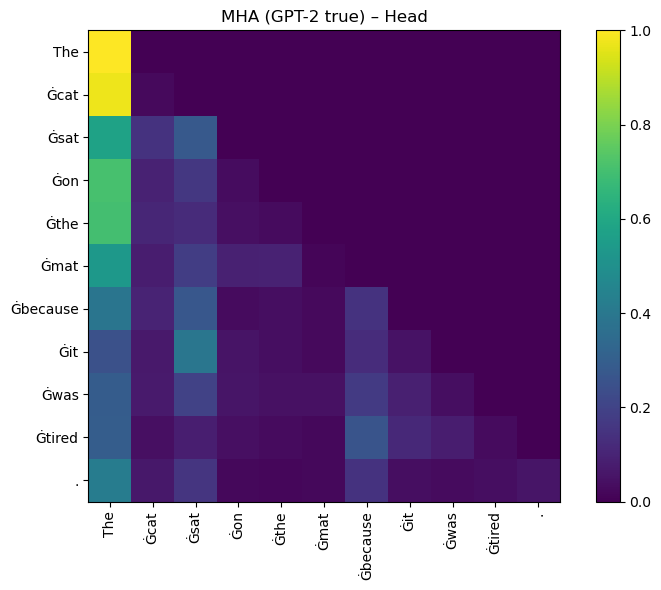

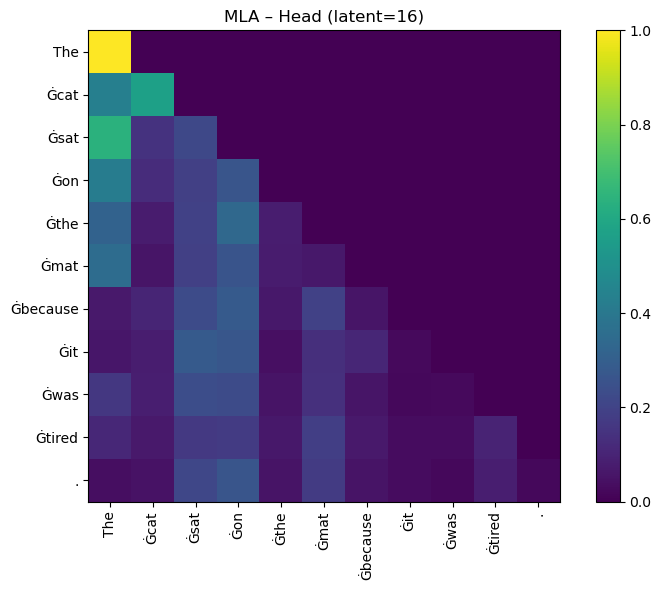

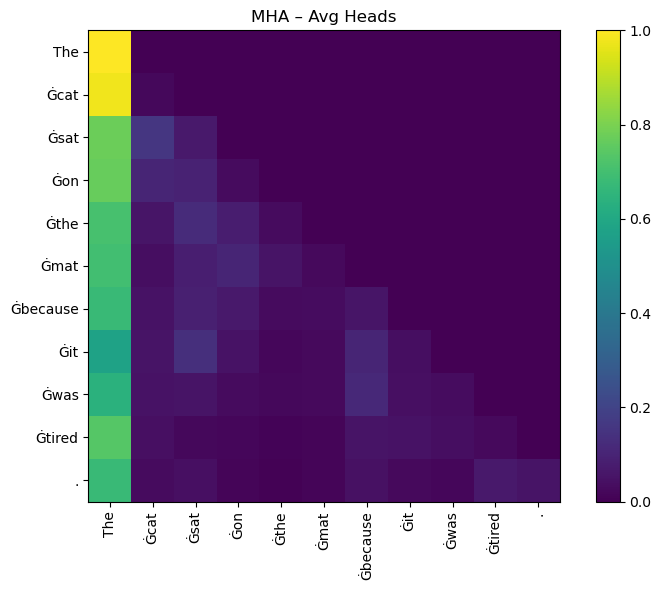

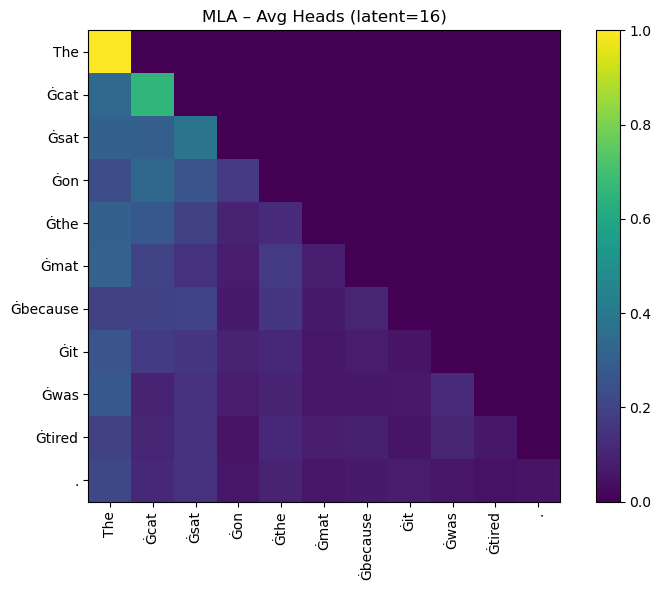


[MHA] top targets from 'Ġit':
  →        The: 0.577244
  →       Ġsat: 0.136280
  →   Ġbecause: 0.105061
  →       Ġcat: 0.052395
  →        Ġon: 0.048856
  →        Ġit: 0.035496

[MLA] top targets from 'Ġit':
  →        The: 0.262597
  →       Ġcat: 0.174643
  →       Ġsat: 0.156742
  →       Ġthe: 0.112897
  →        Ġon: 0.097824
  →   Ġbecause: 0.075001


In [20]:
# -------------------------
# Plot helpers
# -------------------------
def plot(A, title):
    plt.figure(figsize=(8,6))
    plt.imshow(A)
    plt.title(title)
    plt.xticks(range(len(tokens)), tokens, rotation=90)
    plt.yticks(range(len(tokens)), tokens)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# -------------------------
# Heatmaps
# -------------------------
plot(attn_mha_true[0, head_idx].cpu(), "MHA (GPT-2 true) – Head")
plot(attn_mla[0, head_idx].cpu(), f"MLA – Head (latent={LATENT_DIM})")

plot(attn_mha_true[0].mean(0).cpu(), "MHA – Avg Heads")
plot(attn_mla[0].mean(0).cpu(), f"MLA – Avg Heads (latent={LATENT_DIM})")

# -------------------------
# Top targets
# -------------------------
def top_targets(A, label):
    idx = tokens.index("Ġit")
    row = A[idx]
    top = torch.topk(row, 6)
    print(f"\n[{label}] top targets from 'Ġit':")
    for v, j in zip(top.values, top.indices):
        print(f"  → {tokens[j]:>10s}: {v.item():.6f}")

top_targets(attn_mha_true[0].mean(0), "MHA")
top_targets(attn_mla[0].mean(0), "MLA")